# Sinkhorn Distance and Entropic Optimal Transport

Optimal transport compares probability measures by minimizing the cost of moving mass:
$$
\min_{\gamma \in \Pi(a,b)} \langle C, \gamma \rangle,
$$
where $\Pi(a,b)$ is the set of couplings with prescribed marginals $a$ and $b$.

Adding an entropy penalty gives a smooth, scalable formulation:
$$
\min_{\gamma \in \Pi(a,b)} \langle C,\gamma \rangle + \varepsilon \sum_{ij}\gamma_{ij}(\log \gamma_{ij}-1),
$$
whose optimality system is solved by Sinkhorn's matrix scaling algorithm.  
This notebook shows how regularization $\varepsilon$ trades transport sharpness for numerical stability.


## Environment

We import numerical and plotting libraries and define a robust output directory for figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/sinkhorn-distance") if Path("python/sinkhorn-distance").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Build two 1D probability distributions and a quadratic cost matrix

We discretize $x \in [0,1]$, define source/target histograms $(a,b)$, and the squared Euclidean ground cost:
$$
C_{ij} = (x_i - x_j)^2.
$$


In [2]:
n = 180
x = np.linspace(0, 1, n)

def normalize(v):
    v = np.maximum(v, 1e-15)
    return v / v.sum()

a = normalize(0.55*np.exp(-((x-0.25)/0.08)**2) + 0.45*np.exp(-((x-0.50)/0.05)**2))
b = normalize(0.65*np.exp(-((x-0.62)/0.07)**2) + 0.35*np.exp(-((x-0.82)/0.04)**2))
C = (x[:, None] - x[None, :])**2


## Sinkhorn scaling

With $K = \exp(-C/\varepsilon)$, optimal couplings factorize as:
$$
\gamma = \operatorname{diag}(u)\,K\,\operatorname{diag}(v),
$$
and $(u,v)$ are found by alternating row/column normalization to match marginals.


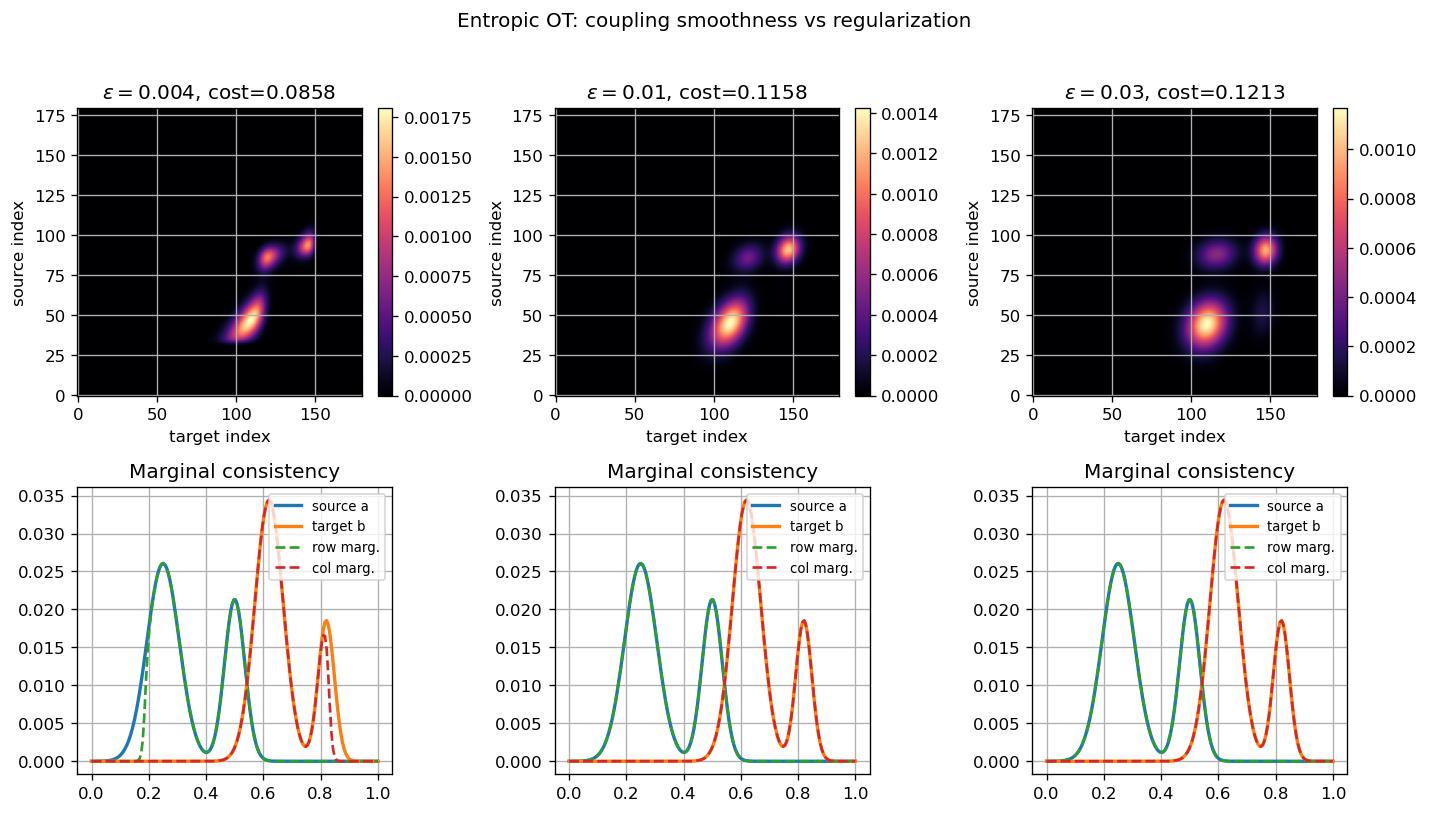

In [3]:
def sinkhorn(a, b, C, eps=0.01, n_iter=500):
    K = np.exp(-C / eps)
    u = np.ones_like(a)
    v = np.ones_like(b)
    for _ in range(n_iter):
        u = a / (K @ v + 1e-16)
        v = b / (K.T @ u + 1e-16)
    gamma = (u[:, None] * K) * v[None, :]
    cost = float((gamma * C).sum())
    return gamma, cost

eps_values = [0.004, 0.01, 0.03]
couplings = []
costs = []
for eps in eps_values:
    G, c = sinkhorn(a, b, C, eps=eps)
    couplings.append(G)
    costs.append(c)

fig, axes = plt.subplots(2, 3, figsize=(12, 6.6))
for j, (eps, G, c) in enumerate(zip(eps_values, couplings, costs)):
    im = axes[0, j].imshow(G, origin="lower", cmap="magma", aspect="auto")
    axes[0, j].set_title(fr"$\varepsilon={eps}$, cost={c:.4f}")
    axes[0, j].set_xlabel("target index")
    axes[0, j].set_ylabel("source index")
    fig.colorbar(im, ax=axes[0, j], fraction=0.046)

    axes[1, j].plot(x, a, label="source a", lw=2)
    axes[1, j].plot(x, b, label="target b", lw=2)
    axes[1, j].plot(x, G.sum(axis=1), "--", lw=1.6, label="row marg.")
    axes[1, j].plot(x, G.sum(axis=0), "--", lw=1.6, label="col marg.")
    axes[1, j].set_title("Marginal consistency")
    axes[1, j].legend(fontsize=8)

fig.suptitle("Entropic OT: coupling smoothness vs regularization", y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- C. Villani, *Topics in Optimal Transportation*.
- G. Peyré and M. Cuturi, *Computational Optimal Transport*.
- J. D. Murray, *Mathematical Biology* (for pattern-forming PDEs).
- R. J. LeVeque, *Finite Difference Methods for ODEs and PDEs*.
